In [2]:
import pandas as pd
import matplotlib.pyplot as plt 

In [9]:
# https://datos.produccion.gob.ar/dataset/percentiles-de-salarios-por-genero-y-actividad/archivo/330b0d2a-7daf-4c94-aa55-ec4790f2b947
df = pd.read_csv('percentiles_todos_total_pub.csv')
df['fecha'] = pd.to_datetime(df['fecha'], format='%Y-%m-%d')
df.head()

,fecha,p10,p25,w_mean,w_median,p75,p90,p99
0,2013-01-01,2400,4048,8387,6313,9923,15454,44799
1,2013-02-01,2370,4050,8033,6271,9788,15164,34356
2,2013-03-01,2500,4431,8669,6808,10598,16116,36174
3,2013-04-01,2715,4581,8829,6998,10874,16483,36076
4,2013-05-01,2770,4594,9116,7092,10965,16959,40737


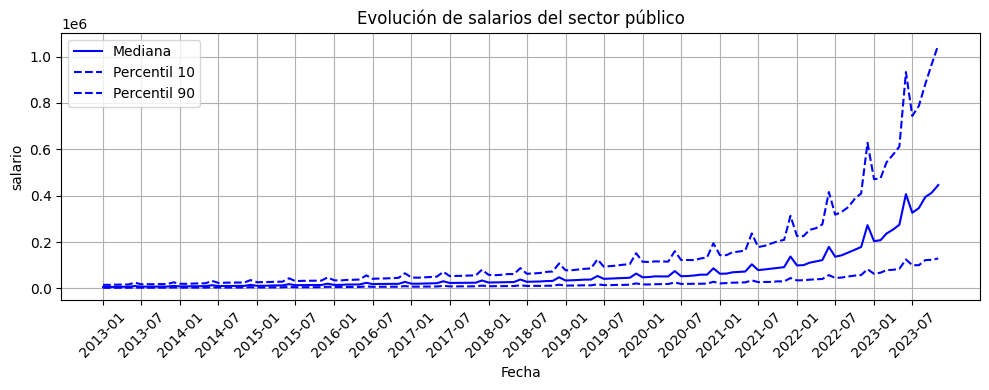

In [25]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(df['fecha'], df['w_median'], label='Mediana', color='blue')
ax.plot(df['fecha'], df['p10'], label='Percentil 10', color='blue', linestyle='dashed')
ax.plot(df['fecha'], df['p90'], label='Percentil 90', color='blue', linestyle='dashed')

ax.set_xlabel('Fecha')
ax.set_title('Evolución de salarios del sector público')
ax.set_xticks(df['fecha'][::6])
ax.set_xticklabels(df['fecha'][::6].dt.strftime('%Y-%m'))
ax.tick_params(axis='x', rotation=45)

ax.set_ylabel('salario')
#ax.set_yscale('log')

ax.legend()

ax.grid()
plt.tight_layout()
plt.show()

In [ ]:
# https://datos.gob.ar/el/dataset/sspm-ipc-nacional-tasas-variacion-mensual-por-categorias-base-dic-2016/archivo/sspm_173.1
ipc_df = pd.read_csv('ipc-categorias-tasas-variacionmensual-basedic-2016.csv') 
ipc_df['indice_tiempo'] = pd.to_datetime(ipc_df['indice_tiempo'], format='%Y-%m-%d')
ipc_df = ipc_df.rename(columns={'indice_tiempo': 'fecha'})
ipc_df['ipc_nucleo_acumulada'] = (1 + ipc_df['ipc_nucleo']).cumprod()
ipc_df['ipc_regulados_acumulada'] = (1 + ipc_df['ipc_regulados']).cumprod()
ipc_df['estacionales_acumulada'] = (1 + ipc_df['estacionales']).cumprod()

ipc_df.head()

,fecha,estacionales,ipc_nucleo,ipc_regulados,ipc_nucleo_acumulada,ipc_regulados_acumulada,estacionales_acumulada
0,2016-12-01,NaN,NaN,NaN,NaN,NaN,NaN
1,2017-01-01,0.016969,0.015039,0.018183,1.015039,1.018183,1.016969
2,2017-02-01,0.006270,0.016813,0.040398,1.032105,1.059316,1.023345
3,2017-03-01,0.023964,0.019331,0.038460,1.052057,1.100057,1.047868
4,2017-04-01,0.032446,0.021114,0.040536,1.074270,1.144649,1.081867


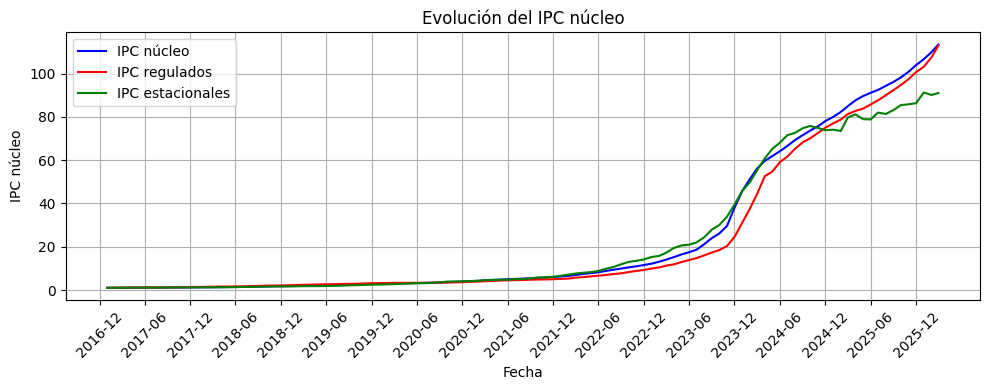

In [39]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ipc_df['fecha'], ipc_df['ipc_nucleo_acumulada'], color='blue', label='IPC núcleo')
ax.plot(ipc_df['fecha'], ipc_df['ipc_regulados_acumulada'], color='red', label='IPC regulados')
ax.plot(ipc_df['fecha'], ipc_df['estacionales_acumulada'], color='green', label='IPC estacionales')

ax.set_xlabel('Fecha')
ax.set_title('Evolución del IPC núcleo')
ax.set_xticks(ipc_df['fecha'][::6])
ax.set_xticklabels(ipc_df['fecha'][::6].dt.strftime('%Y-%m'))
ax.tick_params(axis='x', rotation=45)

ax.set_ylabel('IPC núcleo')
# ax.set_yscale('log')

ax.legend()

ax.grid()

plt.tight_layout()
plt.show()

In [40]:
df_merged = df.merge(ipc_df, on='fecha', how='left')
df_merged.head()

,fecha,p10,p25,w_mean,w_median,p75,p90,p99,estacionales,ipc_nucleo,ipc_regulados,ipc_nucleo_acumulada,ipc_regulados_acumulada,estacionales_acumulada
0,2013-01-01,2400,4048,8387,6313,9923,15454,44799,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-02-01,2370,4050,8033,6271,9788,15164,34356,NaN,NaN,NaN,NaN,NaN,NaN
2,2013-03-01,2500,4431,8669,6808,10598,16116,36174,NaN,NaN,NaN,NaN,NaN,NaN
3,2013-04-01,2715,4581,8829,6998,10874,16483,36076,NaN,NaN,NaN,NaN,NaN,NaN
4,2013-05-01,2770,4594,9116,7092,10965,16959,40737,NaN,NaN,NaN,NaN,NaN,NaN


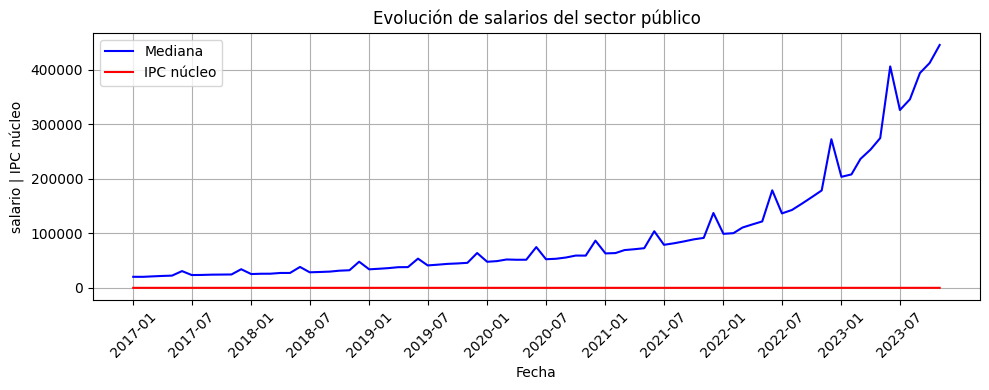

In [48]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(df_merged['fecha'], df_merged['w_median'], label='Mediana', color='blue')
ax.plot(df_merged['fecha'], df_merged['ipc_nucleo_acumulada'], label='IPC núcleo', color='red')

ax.set_xlabel('Fecha')
ax.set_title('Evolución de salarios del sector público')
ax.set_xticks(df_merged['fecha'][::6])
ax.set_xticklabels(df_merged['fecha'][::6].dt.strftime('%Y-%m'))
ax.tick_params(axis='x', rotation=45)

ax.set_ylabel('salario | IPC núcleo')
#ax.set_yscale('log')

ax.legend()

ax.grid()
plt.tight_layout()
plt.show()

In [44]:
df_merged = df_merged.dropna(subset=['ipc_nucleo_acumulada'])
df_merged.head()

,fecha,p10,p25,w_mean,w_median,p75,p90,p99,estacionales,ipc_nucleo,ipc_regulados,ipc_nucleo_acumulada,ipc_regulados_acumulada,estacionales_acumulada
48,2017-01-01,7448,13049,26010,20257,30712,46921,126946,0.016969,0.015039,0.018183,1.015039,1.018183,1.016969
49,2017-02-01,7558,13228,25203,20228,30536,46205,107728,0.006270,0.016813,0.040398,1.032105,1.059316,1.023345
50,2017-03-01,8047,13665,26316,21029,31431,47596,115724,0.023964,0.019331,0.038460,1.052057,1.100057,1.047868
51,2017-04-01,8080,14160,26789,21839,32424,48875,111906,0.032446,0.021114,0.040536,1.074270,1.144649,1.081867
52,2017-05-01,8225,14367,27604,22431,33302,50598,117029,0.008013,0.016568,0.010405,1.092069,1.156559,1.090536


In [45]:
df_merged['w_median_prop'] = df_merged['w_median'] / df_merged['w_median'].iloc[0]

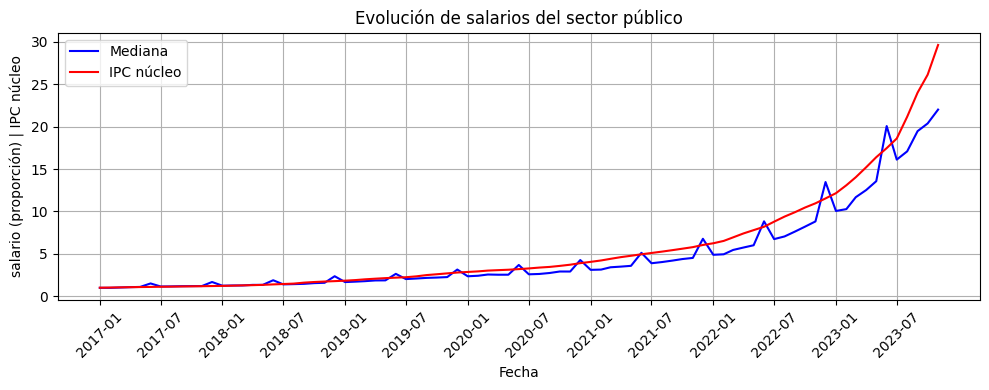

In [49]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(df_merged['fecha'], df_merged['w_median_prop'], label='Mediana', color='blue')
ax.plot(df_merged['fecha'], df_merged['ipc_nucleo_acumulada'], label='IPC núcleo', color='red')

ax.set_xlabel('Fecha')
ax.set_title('Evolución de salarios del sector público')
ax.set_xticks(df_merged['fecha'][::6])
ax.set_xticklabels(df_merged['fecha'][::6].dt.strftime('%Y-%m'))
ax.tick_params(axis='x', rotation=45)

ax.set_ylabel('salario (proporción) | IPC núcleo')
#ax.set_yscale('log')

ax.legend()

ax.grid()
plt.tight_layout()
plt.show()

In [50]:
df_merged['w_median_prop_real'] = df_merged['w_median_prop'] / df_merged['ipc_nucleo_acumulada'] 

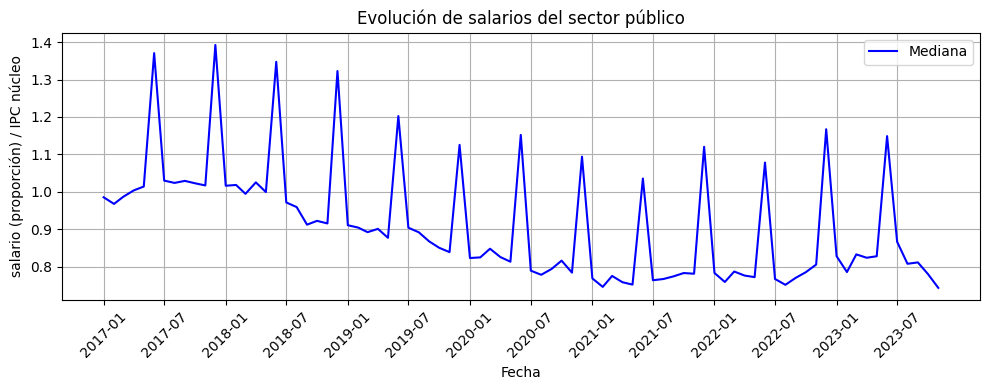

In [51]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(df_merged['fecha'], df_merged['w_median_prop_real'], label='Mediana', color='blue')

ax.set_xlabel('Fecha')
ax.set_title('Evolución de salarios del sector público')
ax.set_xticks(df_merged['fecha'][::6])
ax.set_xticklabels(df_merged['fecha'][::6].dt.strftime('%Y-%m'))
ax.tick_params(axis='x', rotation=45)

ax.set_ylabel('salario (proporción) / IPC núcleo')
#ax.set_yscale('log')

ax.legend()

ax.grid()
plt.tight_layout()
plt.show()